<a href="https://colab.research.google.com/github/hdpark1208/StudyCode/blob/main/Algorithm/BJ/%EA%B2%BD%EC%82%AC%EB%A1%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 경사로

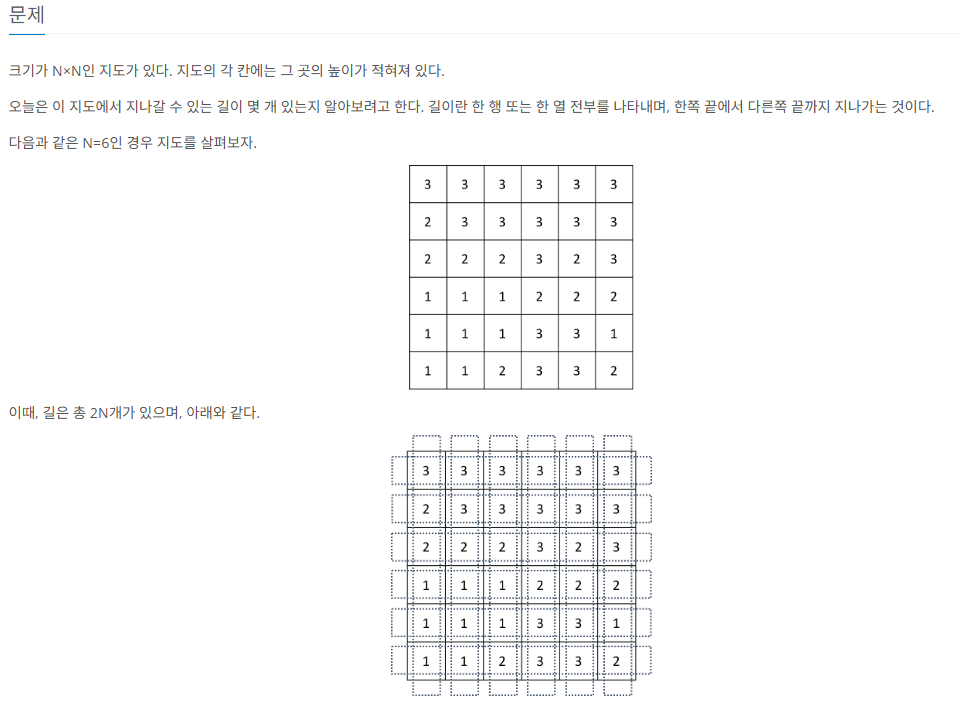

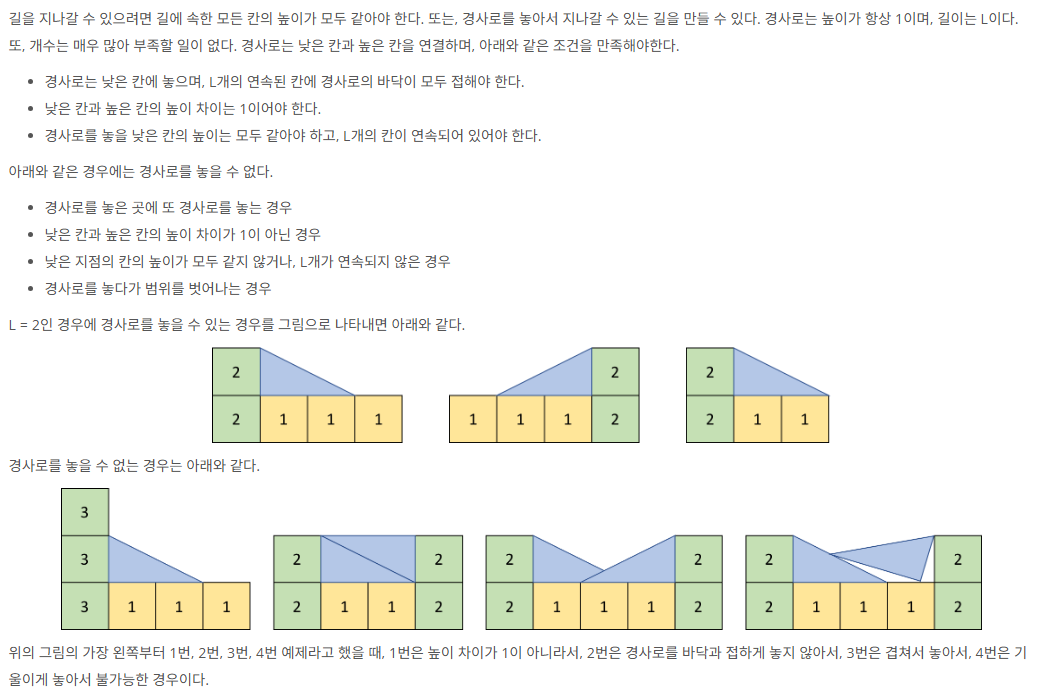

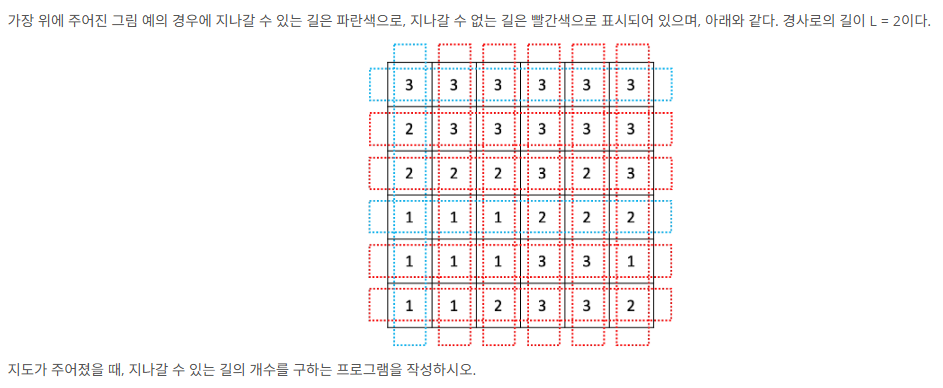

## 입력 출력 및 예제


* 입력

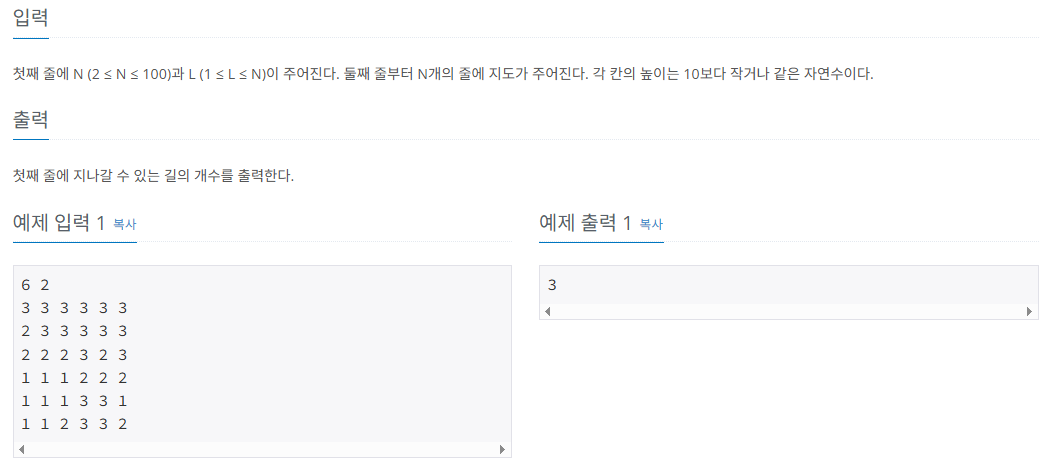

* 출력

* 예제

## 구상

* 높이가 같으면 진행, 다르다면,
    - 높이 차가 1
    - 경사로의 길이 만큼의 여유 공간이 있어야함

* 패딩

## 코드

In [ ]:
def path(road, N, L):
    used = [False] * (N + 2 * L)

    pre_h = road[L]

    for i, h in enumerate(road[L:L+N], L):
        if h == pre_h:
            continue

        # 높아지는 경우: 왼쪽 L칸 검사
        if h - pre_h == 1:
            for j in range(i - L, i):
                if road[j] != pre_h or used[j]:
                    return False
                used[j] = True

        # 낮아지는 경우: 오른쪽 L칸 검사
        elif pre_h - h == 1:
            for j in range(i, i + L):
                if road[j] != h or used[j]:
                    return False
                used[j] = True

        else:
            return False

        pre_h = h

    return True


N, L = map(int, input().split())
board = []
for _ in range(N):
    board.append(list(map(int, input().split())))

new_board = []

# 위 padding
for _ in range(L):
    new_board.append([-1] * (N + 2 * L))

# 가운데
for row in board:
    new_board.append([-1] * L + row + [-1] * L)

# 아래 padding
for _ in range(L):
    new_board.append([-1] * (N + 2 * L))

board = new_board

# rows: 가운데 N개 행
rows = board[L:N+L]

# cols: 전치 후 가운데 N개 열
cols = [list(col) for col in zip(*board)][L:N+L]

result = 0

for i in range(N):
    if path(rows[i], N, L):
        result += 1

    if path(cols[i], N, L):
        result += 1

print(result)

In [113]:
print(list(zip(board)))

[([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1],), ([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1],), ([-1, -1, 3, 2, 1, 1, 2, 3, -1, -1],), ([-1, -1, 3, 2, 2, 1, 2, 3, -1, -1],), ([-1, -1, 3, 2, 2, 2, 3, 3, -1, -1],), ([-1, -1, 3, 3, 3, 3, 3, 3, -1, -1],), ([-1, -1, 3, 3, 3, 3, 2, 2, -1, -1],), ([-1, -1, 3, 3, 3, 3, 2, 2, -1, -1],), ([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1],), ([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1],)]


In [110]:
board[:][2]

[-1, -1, 3, 2, 1, 1, 2, 3, -1, -1]

In [108]:
board[2]

[-1, -1, 3, 2, 1, 1, 2, 3, -1, -1]

### 메모



* 확실히, 깔끔하게 짜는게 전체적으로 시간을 더 단축 시킨다!
* 패딩 처리 시 인덱스, 구성 원소에 혼돈이 와서 시간이 오래 걸렸다. 꼼꼼하게 주석처리 해가면서 얽히지 않도록 하자
* zip(* : 전치), enumerate, padding . 다양하게 썼다